### POT algoritma darbības piemērs


In [9]:
import sys
import os

PROJECT_ROOT = os.path.abspath("..")  # no examples uz root
sys.path.insert(0, PROJECT_ROOT)

# mainīgie
data_csv = os.path.join(PROJECT_ROOT, "data/raw/A_K_aukstais_udens.csv")

time_column_name = 'timestamp_unix'
value_column_name = 'value'
datetime_column_name = 'ts'


from src.prepare_data import(
    prepare_data,
    preprocess_data,
    day_use_dataset
)
from src.anomaly_detection_algorithms.pot import (
    PeakOverThreshold,
    Grimshaw,
    CalcThreshold
)
from src.visualizations import (
    visualize_pot
)

#### Datu priekšapstrāde


In [10]:
prepared_data = prepare_data(data_csv, time_column_name, value_column_name, datetime_column_name)
preprocessed_data = preprocess_data(prepared_data, time_column_name, value_column_name, datetime_column_name)
days_df = day_use_dataset(preprocessed_data)


In [12]:
days_df

,date,delta
0,2024-01-01,0.579900
1,2024-01-02,0.690000
2,2024-01-03,0.670100
3,2024-01-04,0.790000
4,2024-01-05,0.690000
...,...,...
361,2024-12-27,0.621522
362,2024-12-28,0.552853
363,2024-12-29,0.535725
364,2024-12-30,0.627818


#### POT algoritms


In [16]:
#mainīgie
data = days_df["delta"].to_numpy()
threshold = 0.8
init_threshold = 0.5

#POT algoritms
threshold, init_threshold = PeakOverThreshold(
    data = data,
    risk=1e-2,
    init_level=0.9,
    num_candidates=10,
    epsilon=1e-8,
)

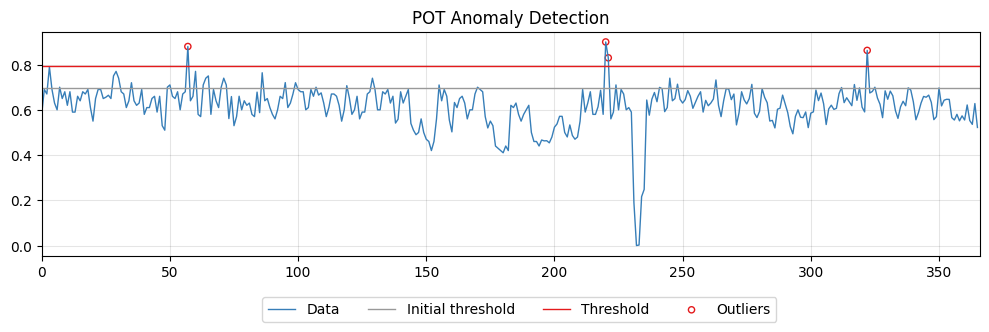

In [17]:
visualize_pot(
    data=data,
    threshold=threshold,
    init_threshold=init_threshold
)